# 01 — Daycare Data Processing
> ETL from OpenStreetMap: load, clean, estimate missing capacities, export.

---

## Setup

In [ ]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

sys.path.insert(0, str(Path("../src").resolve()))

from config import (
    DAYCARE_OSM_FILE as GEOJSON_PATH,
    DAYCARE_PROCESSED_FILE as OUTPUT_FILE,
    PROJ_CRS,
    TARGET_CAPACITY,
    WFS_URL,
)

## 1. Data Loading

Load the raw daycare GeoJSON and the Berlin district boundaries from the WFS endpoint.
The preview confirms that both inputs are available and structurally plausible before processing.

In [2]:
gdf = gpd.read_file(GEOJSON_PATH)
berlin_districts = gpd.read_file(WFS_URL)

print("\nDaycare data:")
display(gdf.head())
print("\nDistrict data:")
display(berlin_districts.head())


Kita Data:


,id,@id,access,addr:city,addr:country,addr:housename,addr:housenumber,addr:inclusion,addr:place,addr:postcode,...,website,website2,website:menu,website_1,wheelchair,wheelchair:description,wikidata,wikimedia_commons,wikipedia,geometry
0,relation/9881612,relation/9881612,None,None,None,None,None,None,None,None,...,http://www.sankt-stephanus-haselhorst.de/kita....,None,None,None,None,None,None,None,None,"POLYGON ((13.2441 52.54235, 13.24394 52.54242,..."
1,relation/16630749,relation/16630749,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((13.33227 52.45555, 13.33205 52.45564..."
2,relation/16641659,relation/16641659,None,Berlin,DE,None,75,None,None,12249,...,https://www.kitas-sued-west.de/content/integra...,None,None,None,None,None,None,None,None,"POLYGON ((13.34384 52.42991, 13.34447 52.42936..."
3,relation/16750713,relation/16750713,None,Berlin,DE,None,12,None,None,12249,...,https://www.milchbartpiraten.de/,None,None,None,None,None,None,None,None,"POLYGON ((13.34305 52.43249, 13.34306 52.43248..."
4,relation/17333392,relation/17333392,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((13.33367 52.45912, 13.33296 52.45908..."



District Data:


,gml_id,objectid,lan,namlan,gem,namgem,name,geometry
0,bezirksgrenzen.1,1,11,Berlin,003,Pankow,11000003,"MULTIPOLYGON (((399003.49 5834202.526, 398981...."
1,bezirksgrenzen.2,2,11,Berlin,004,Charlottenburg-Wilmersdorf,11000004,"MULTIPOLYGON (((387115.47 5816898.439, 387126...."
2,bezirksgrenzen.3,3,11,Berlin,010,Marzahn-Hellersdorf,11000010,"MULTIPOLYGON (((406879.044 5816643.302, 406891..."
3,bezirksgrenzen.4,4,11,Berlin,002,Friedrichshain-Kreuzberg,11000002,"MULTIPOLYGON (((396077.557 5817819.888, 396079..."
4,bezirksgrenzen.5,5,11,Berlin,012,Reinickendorf,11000012,"MULTIPOLYGON (((389990.688 5829740.615, 390001..."


### Cleaning and spatial assignment

Convert the raw inputs to a common projected CRS, standardize missing values, and attach each daycare center to its district.
The quick map provides a visual sanity check before capacity estimation.

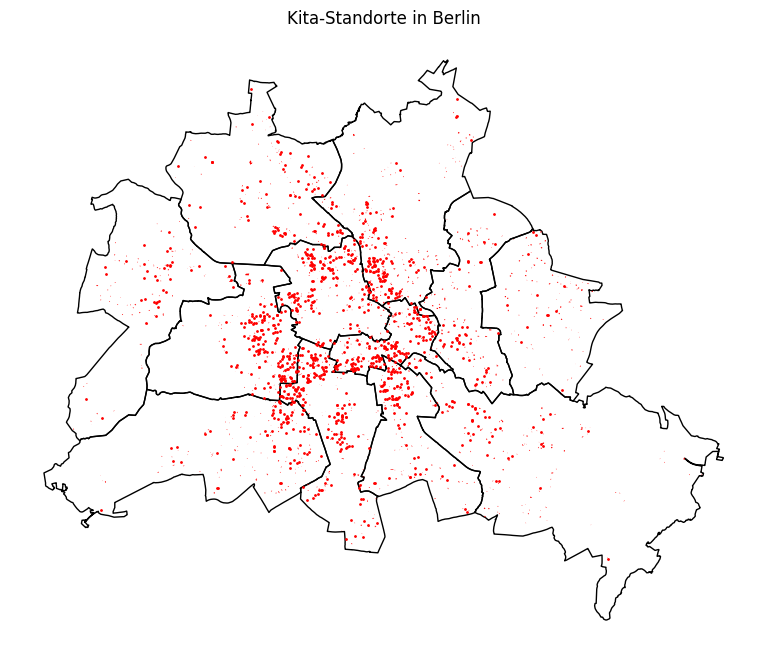

In [3]:
if gdf.crs.is_geographic:
    gdf = gdf.to_crs(PROJ_CRS)
berlin_districts = berlin_districts.to_crs(gdf.crs)

gdf = gdf.replace({None: np.nan})
gdf['name'] = gdf['name'].fillna("unknown")
gdf['capacity'] = pd.to_numeric(gdf['capacity'], errors='coerce')

gdf = gpd.sjoin(
    gdf,
    berlin_districts[['geometry', 'namgem']], 
    how="left",
    predicate="within"
)

gdf['suburb'] = gdf['namgem']
gdf = gdf.drop(columns=['namgem', 'index_right'])

fig, ax = plt.subplots(figsize=(12, 8))
berlin_districts.plot(ax=ax, edgecolor='black', facecolor='none')
gdf.plot(ax=ax, color='red', markersize=1)
plt.title('Kita-Standorte in Berlin')
plt.axis('off')
plt.show()

### Geometry split and known capacities

Separate point features from polygon features because they need different estimation strategies.
The histogram of known capacities serves as a baseline check before prediction.

Nodes: 1137, Polygons: 1197


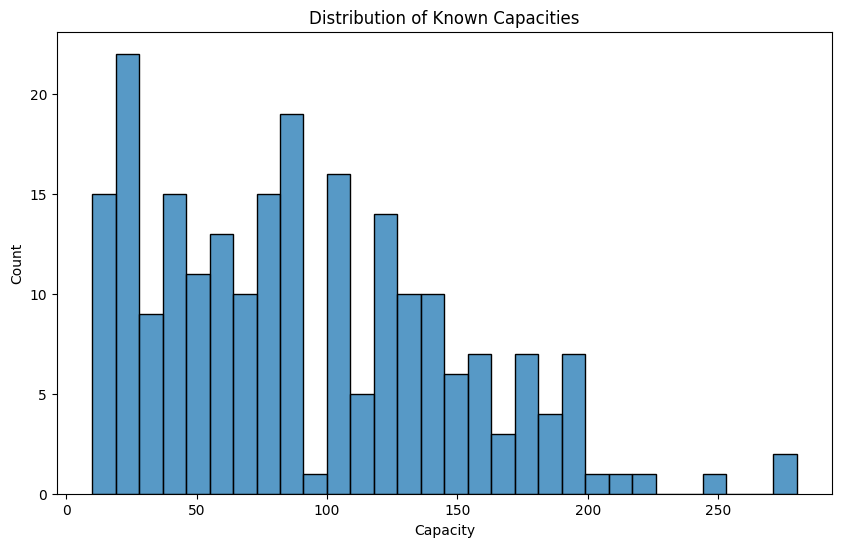

In [5]:
nodes = gdf[gdf.geometry.type == 'Point'].copy()
polygons = gdf[gdf.geometry.type == 'Polygon'].copy()

polygons['area'] = polygons.geometry.area.round().astype(float)
polygons['geometry'] = polygons.geometry.centroid

print(f"Nodes: {len(nodes)}, Polygons: {len(polygons)}")

# Create a combined dataset of known capacities from both nodes and polygons
known_capacities = pd.concat([
    nodes[nodes['capacity'].notna()]['capacity'],
    polygons[polygons['capacity'].notna()]['capacity']
])

# Visualize the distribution of known capacities using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(known_capacities, bins=30)
plt.title('Distribution of Known Capacities')
plt.xlabel('Capacity')
plt.ylabel('Count')
plt.show()

### Polygon-based capacity estimation

Fit a simple regression from building area to capacity for polygon daycare features with known values.
Use that model to estimate missing capacities and cap extreme predictions with a basic outlier rule.

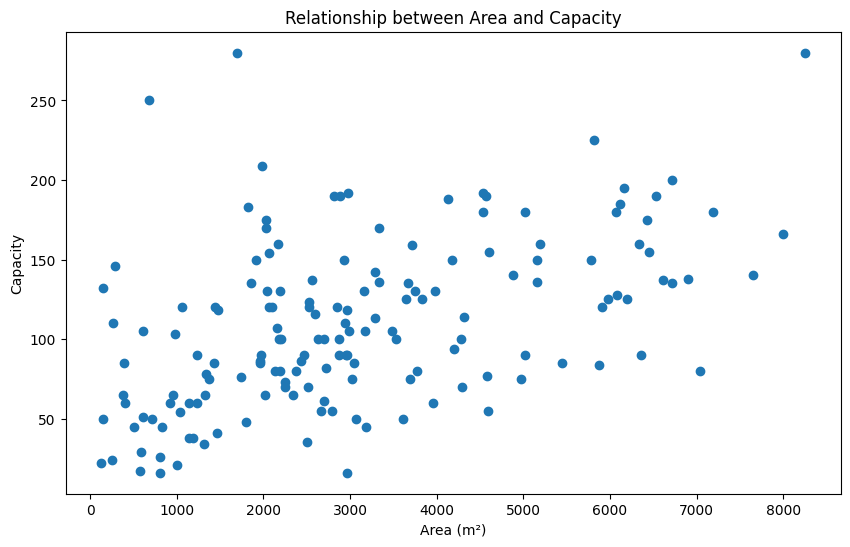


Regression Statistics:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         68.5881      6.930      9.898      0.000      54.901      82.276
x1             0.0132      0.002      6.959      0.000       0.009       0.017


In [6]:
valid_data = polygons[polygons['capacity'].notna() & polygons['area'].notna()]

plt.figure(figsize=(10, 6))
plt.scatter(valid_data['area'], valid_data['capacity'])
plt.xlabel('Area (m²)') 
plt.ylabel('Capacity')
plt.title('Relationship between Area and Capacity')
plt.show()

X = valid_data['area'].values.reshape(-1, 1)
X = sm.add_constant(X)
y = valid_data['capacity'].values
model = sm.OLS(y, X).fit()

print("\nRegression Statistics:")
print(model.summary().tables[1])

#### Interpretation of the Regression Analysis

The regression analysis shows a significant relationship between building area and daycare capacity:

1. **Base Capacity** (const = 68.59):
- On average, a daycare center has a "base capacity" of about 69 places, regardless of its size
- The value is statistically highly significant (p < 0.001)

2. **Area Effect** (x1 = 0.0132):
- For each additional square meter of area, there are on average 0.0132 more care places
- In other words: For every 100m² of additional area, there are about 1.32 additional care places
- This relationship is also statistically highly significant (p < 0.001)

The confidence intervals ([0.025 0.975]) show that the true values are between 55 and 82 places for the base capacity and between 0.009 and 0.017 places per m² for the area effect with 95% probability.

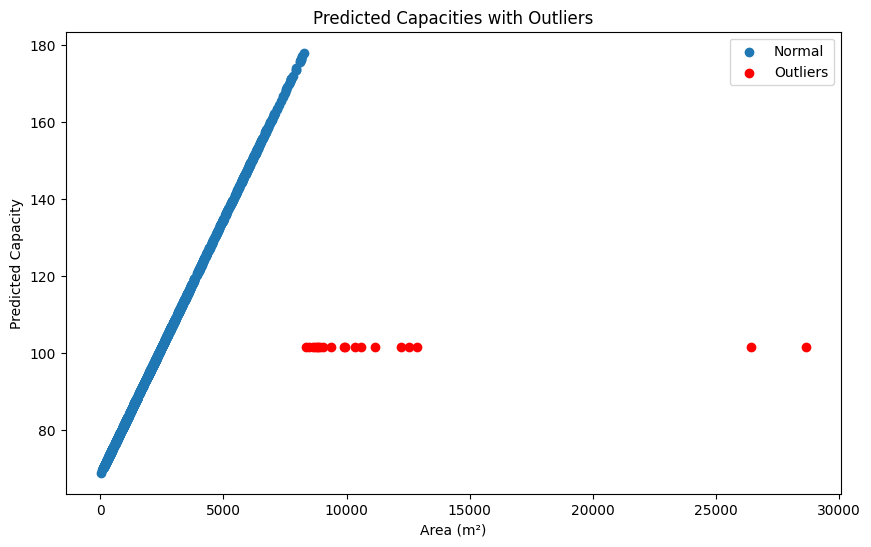

In [7]:
# Predict capacity for polygons with missing values
missing_capacity = polygons[polygons['capacity'].isna()].copy()
X_pred = sm.add_constant(missing_capacity['area'].values.reshape(-1, 1))
missing_capacity['predicted_capacity'] = model.predict(X_pred)

# Transfer predictions back to main polygons DataFrame
polygons.loc[polygons['capacity'].isna(), 'predicted_capacity'] = missing_capacity['predicted_capacity']

# Calculate confidence intervals for predictions
prediction = model.get_prediction(X_pred)
missing_capacity['conf_lower'], missing_capacity['conf_upper'] = prediction.conf_int().T

# Identify outliers using IQR method
Q1 = missing_capacity['predicted_capacity'].quantile(0.25)
Q3 = missing_capacity['predicted_capacity'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
missing_capacity['is_outlier'] = missing_capacity['predicted_capacity'] > upper_bound

# Replace outliers with the median of the non-outliers
median_value = missing_capacity[~missing_capacity['is_outlier']]['predicted_capacity'].median()
missing_capacity.loc[missing_capacity['is_outlier'], 'predicted_capacity'] = median_value


# Visualize predictions highlighting outliers
plt.figure(figsize=(10, 6))
plt.scatter(missing_capacity[~missing_capacity['is_outlier']]['area'], missing_capacity[~missing_capacity['is_outlier']]['predicted_capacity'],label='Normal')
plt.scatter(missing_capacity[missing_capacity['is_outlier']]['area'],missing_capacity[missing_capacity['is_outlier']]['predicted_capacity'],color='red', label='Outliers')
plt.xlabel('Area (m²)')
plt.ylabel('Predicted Capacity')
plt.title('Predicted Capacities with Outliers')
plt.legend()
plt.show()

### Point-based capacity estimation

For daycare points without known capacities, use district medians with a small random variation and a plausible min/max clamp.
This keeps the estimation strategy simple while reflecting local differences in daycare size.

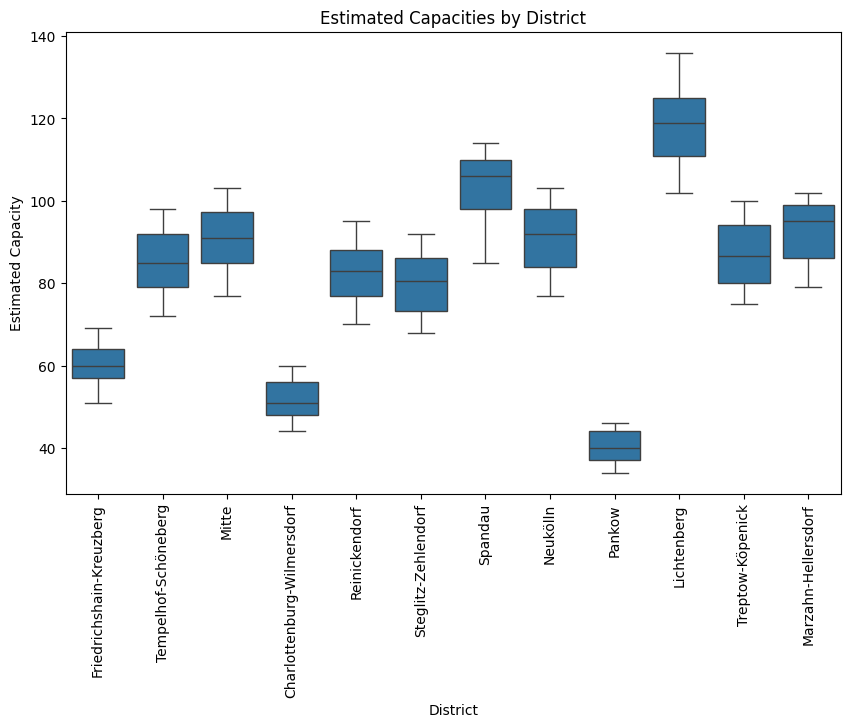

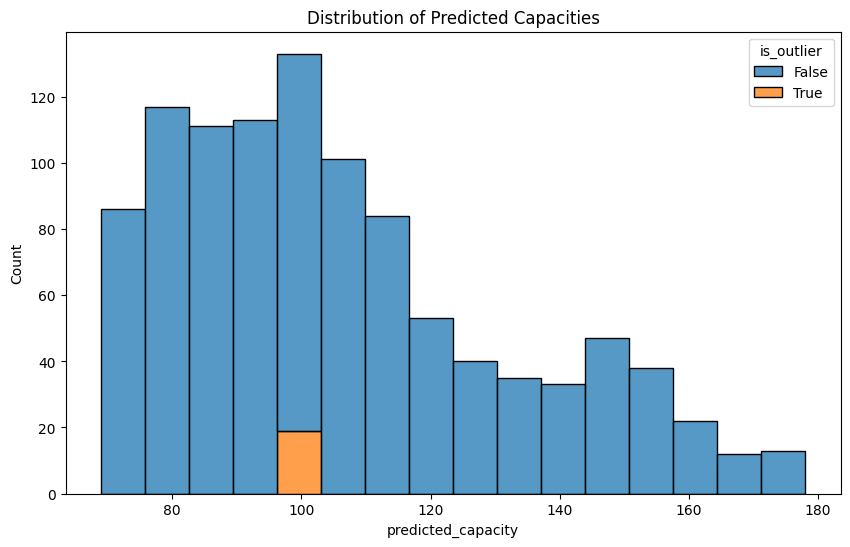

In [8]:
# Calculate district-wise medians
known_capacities = pd.concat([
    nodes[nodes['capacity'].notna()][['capacity', 'suburb']],
    polygons[['capacity', 'suburb']]
])
global_median = known_capacities['capacity'].median()
district_medians = known_capacities.groupby('suburb')['capacity'].median()

nodes_missing = nodes[nodes['capacity'].isna()].copy()
nodes_missing['predicted_capacity'] = np.nan

for suburb in nodes_missing['suburb'].unique():
    mask = nodes_missing['suburb'] == suburb
    n_samples = mask.sum()

    base_capacity = district_medians.get(suburb, global_median)
    variation = np.random.uniform(0.85, 1.15, n_samples)
    capacities = (base_capacity * variation).round()
    capacities = np.clip(capacities, 10, 200)

    nodes_missing.loc[mask, 'predicted_capacity'] = capacities

nodes.loc[nodes['capacity'].isna(), 'predicted_capacity'] = nodes_missing['predicted_capacity']

plt.figure(figsize=(10, 6))
sns.boxplot(x='suburb', y='predicted_capacity', data=nodes_missing)
plt.xticks(rotation=90)
plt.title('Estimated Capacities by District')
plt.xlabel('District')
plt.ylabel('Estimated Capacity')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=missing_capacity, x='predicted_capacity', hue='is_outlier', multiple="stack")
plt.title('Distribution of Predicted Capacities')
plt.show()

### Scaling to the target capacity

Scale the estimated values so the combined dataset matches the known Berlin-wide target capacity.
This preserves the relative structure of the predictions while calibrating the total.

In [9]:
# Calculate the current total capacity
total_capacity = (
    nodes['capacity'].fillna(nodes['predicted_capacity']).sum() +
    polygons['capacity'].fillna(polygons['predicted_capacity']).sum()
)

# Adjust to target capacity
scale_factor = TARGET_CAPACITY / total_capacity
print(f"Scale factor: {scale_factor:.3f}")

# Scale the estimated capacities
for gdf in [nodes, polygons]:
    mask = gdf['capacity'].isna()
    gdf.loc[mask, 'predicted_capacity'] = (
        gdf.loc[mask, 'predicted_capacity'] * scale_factor
    ).round()

Scale factor: 0.937


## Results / Summary

Merge the point and polygon datasets into one final daycare layer with observed and predicted capacities.
The summary statistics and plots provide a final plausibility check before export.

In [10]:
columns = ['name', 'id', 'capacity', 'predicted_capacity', 'geometry', 'suburb']
combined = pd.concat([nodes[columns], polygons[columns]], ignore_index=True)

combined['final_capacity'] = combined['capacity'].fillna(combined['predicted_capacity'])
combined['capacity_source'] = np.where(
    combined['capacity'].isna(),
    'predicted',
    'observed'
)

In [11]:
print("\nFinal statistics:")
print(f"Total daycare centers: {len(combined):,}")
print(f"Estimated capacities: {(combined['capacity_source'] == 'predicted').sum():,}")
print(f"Total capacity: {combined['final_capacity'].sum():,.0f}")

district_stats = combined.groupby('suburb').agg({
    'final_capacity': ['sum', 'mean', 'count']
}).round(0)
display(district_stats)


Finale Statistiken:
Gesamtanzahl Kitas: 2,334
Geschätzte Kapazitäten: 2,109
Gesamtkapazität: 201,261


final_capacity             
                                      sum   mean count
suburb                                                
Charlottenburg-Wilmersdorf        13289.0   61.0   217
Friedrichshain-Kreuzberg          16383.0   72.0   228
Lichtenberg                       17236.0  115.0   150
Marzahn-Hellersdorf               12251.0  107.0   115
Mitte                             22961.0   89.0   257
Neukölln                          15980.0   93.0   171
Pankow                            21636.0   75.0   289
Reinickendorf                     13894.0   88.0   158
Spandau                           11396.0   99.0   115
Steglitz-Zehlendorf               16662.0   87.0   192
Tempelhof-Schöneberg              23251.0   85.0   275
Treptow-Köpenick                  15705.0   97.0   162

## Export

Final processed dataset written to `data/processed/daycare_centers_processed.geojson`.

In [12]:
final_columns = ['name', 'id', 'suburb', 'final_capacity', 'capacity_source', 'geometry']
combined = combined[final_columns]

OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
combined.to_file(OUTPUT_FILE, driver='GeoJSON')
print(f"\nData saved to: {OUTPUT_FILE}")


Data saved to: ../data/processed/kitas_processed.geojson


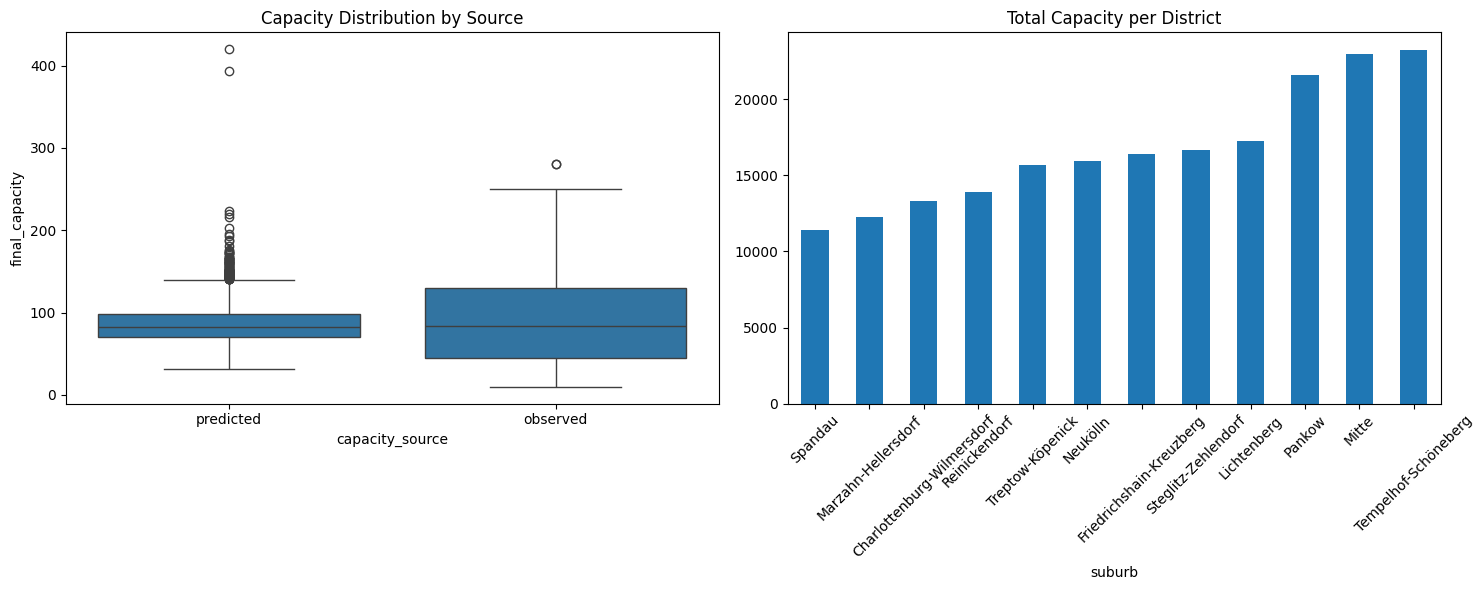

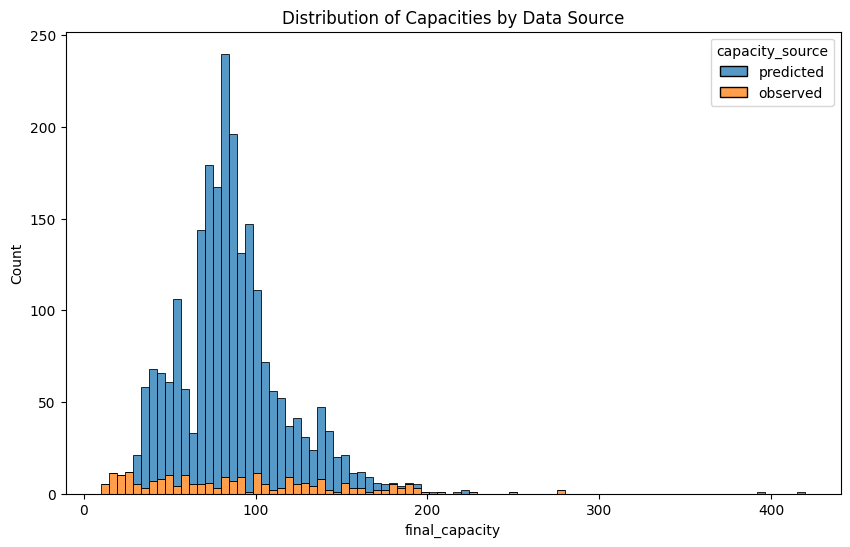

In [13]:
# Create visualization layout with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Create boxplot showing capacity distribution by data source (observed vs predicted)
sns.boxplot(x='capacity_source', y='final_capacity', data=combined, ax=ax1)
ax1.set_title('Capacity Distribution by Source')

# Calculate and plot total capacity per district as bar chart
district_stats = combined.groupby('suburb')['final_capacity'].sum().sort_values()
district_stats.plot(kind='bar', ax=ax2)
ax2.set_title('Total Capacity per District')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Additional analysis: Create stacked histogram showing capacity distribution by source
plt.figure(figsize=(10, 6))
sns.histplot(data=combined, x='final_capacity', hue='capacity_source', multiple="stack")
plt.title('Distribution of Capacities by Data Source')
plt.show()